<a href="https://colab.research.google.com/github/henry-design/stb/blob/main/notebooks/train-yolo11-object-detection-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

### Configure API keys

To fine-tune YOLO11, you need to provide your Roboflow API key. Follow these steps:

- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑). Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Tue Dec 23 13:23:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLO11 via Ultralytics

In [3]:
%pip install "ultralytics<=8.3.40" supervision roboflow
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 38.7/112.6 GB disk)


## Fine-tune YOLO11 on custom dataset

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`. In this tutorial, we will use one of the [datasets](https://universe.roboflow.com/liangdianzhong/-qvdww) available on [Roboflow Universe](https://universe.roboflow.com/). When downloading, make sure to select the `yolov11` export format.

In [12]:
!mkdir {HOME}/datasets
%cd {HOME}/datasets

from google.colab import userdata
from roboflow import Roboflow


from roboflow import Roboflow
rf = Roboflow(api_key="Dj4vq7q9yoCP5QfGZABH")
project = rf.workspace("test-fnyyf").project("water-meter-dataset-op5vi")
version = project.version(3)
dataset = version.download("yolov11")


/content/datasets
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Water-Meter-Dataset-3 in yolov11:: 100%|██████████| 47983/47983 [00:12<00:00, 3748.38it/s]


## Custom Training

In [13]:
%cd {HOME}

!yolo task=detect mode=train model=yolo11s.pt data={dataset.location}/data.yaml epochs=10 imgsz=640 plots=True

/content
100% 18.4M/18.4M [00:00<00:00, 211MB/s]
New https://pypi.org/project/ultralytics/8.3.241 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/Water-Meter-Dataset-3/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=Fals

**NOTE:** The results of the completed training are saved in `{HOME}/runs/detect/train/`. Let's examine them.

In [14]:
!ls {HOME}/runs/detect/train/

args.yaml					    results.png
confusion_matrix_normalized.png			    train_batch0.jpg
confusion_matrix.png				    train_batch1.jpg
events.out.tfevents.1766496449.52c14df7964b.2675.0  train_batch2.jpg
F1_curve.png					    val_batch0_labels.jpg
labels_correlogram.jpg				    val_batch0_pred.jpg
labels.jpg					    val_batch1_labels.jpg
P_curve.png					    val_batch1_pred.jpg
PR_curve.png					    val_batch2_labels.jpg
R_curve.png					    val_batch2_pred.jpg
results.csv					    weights


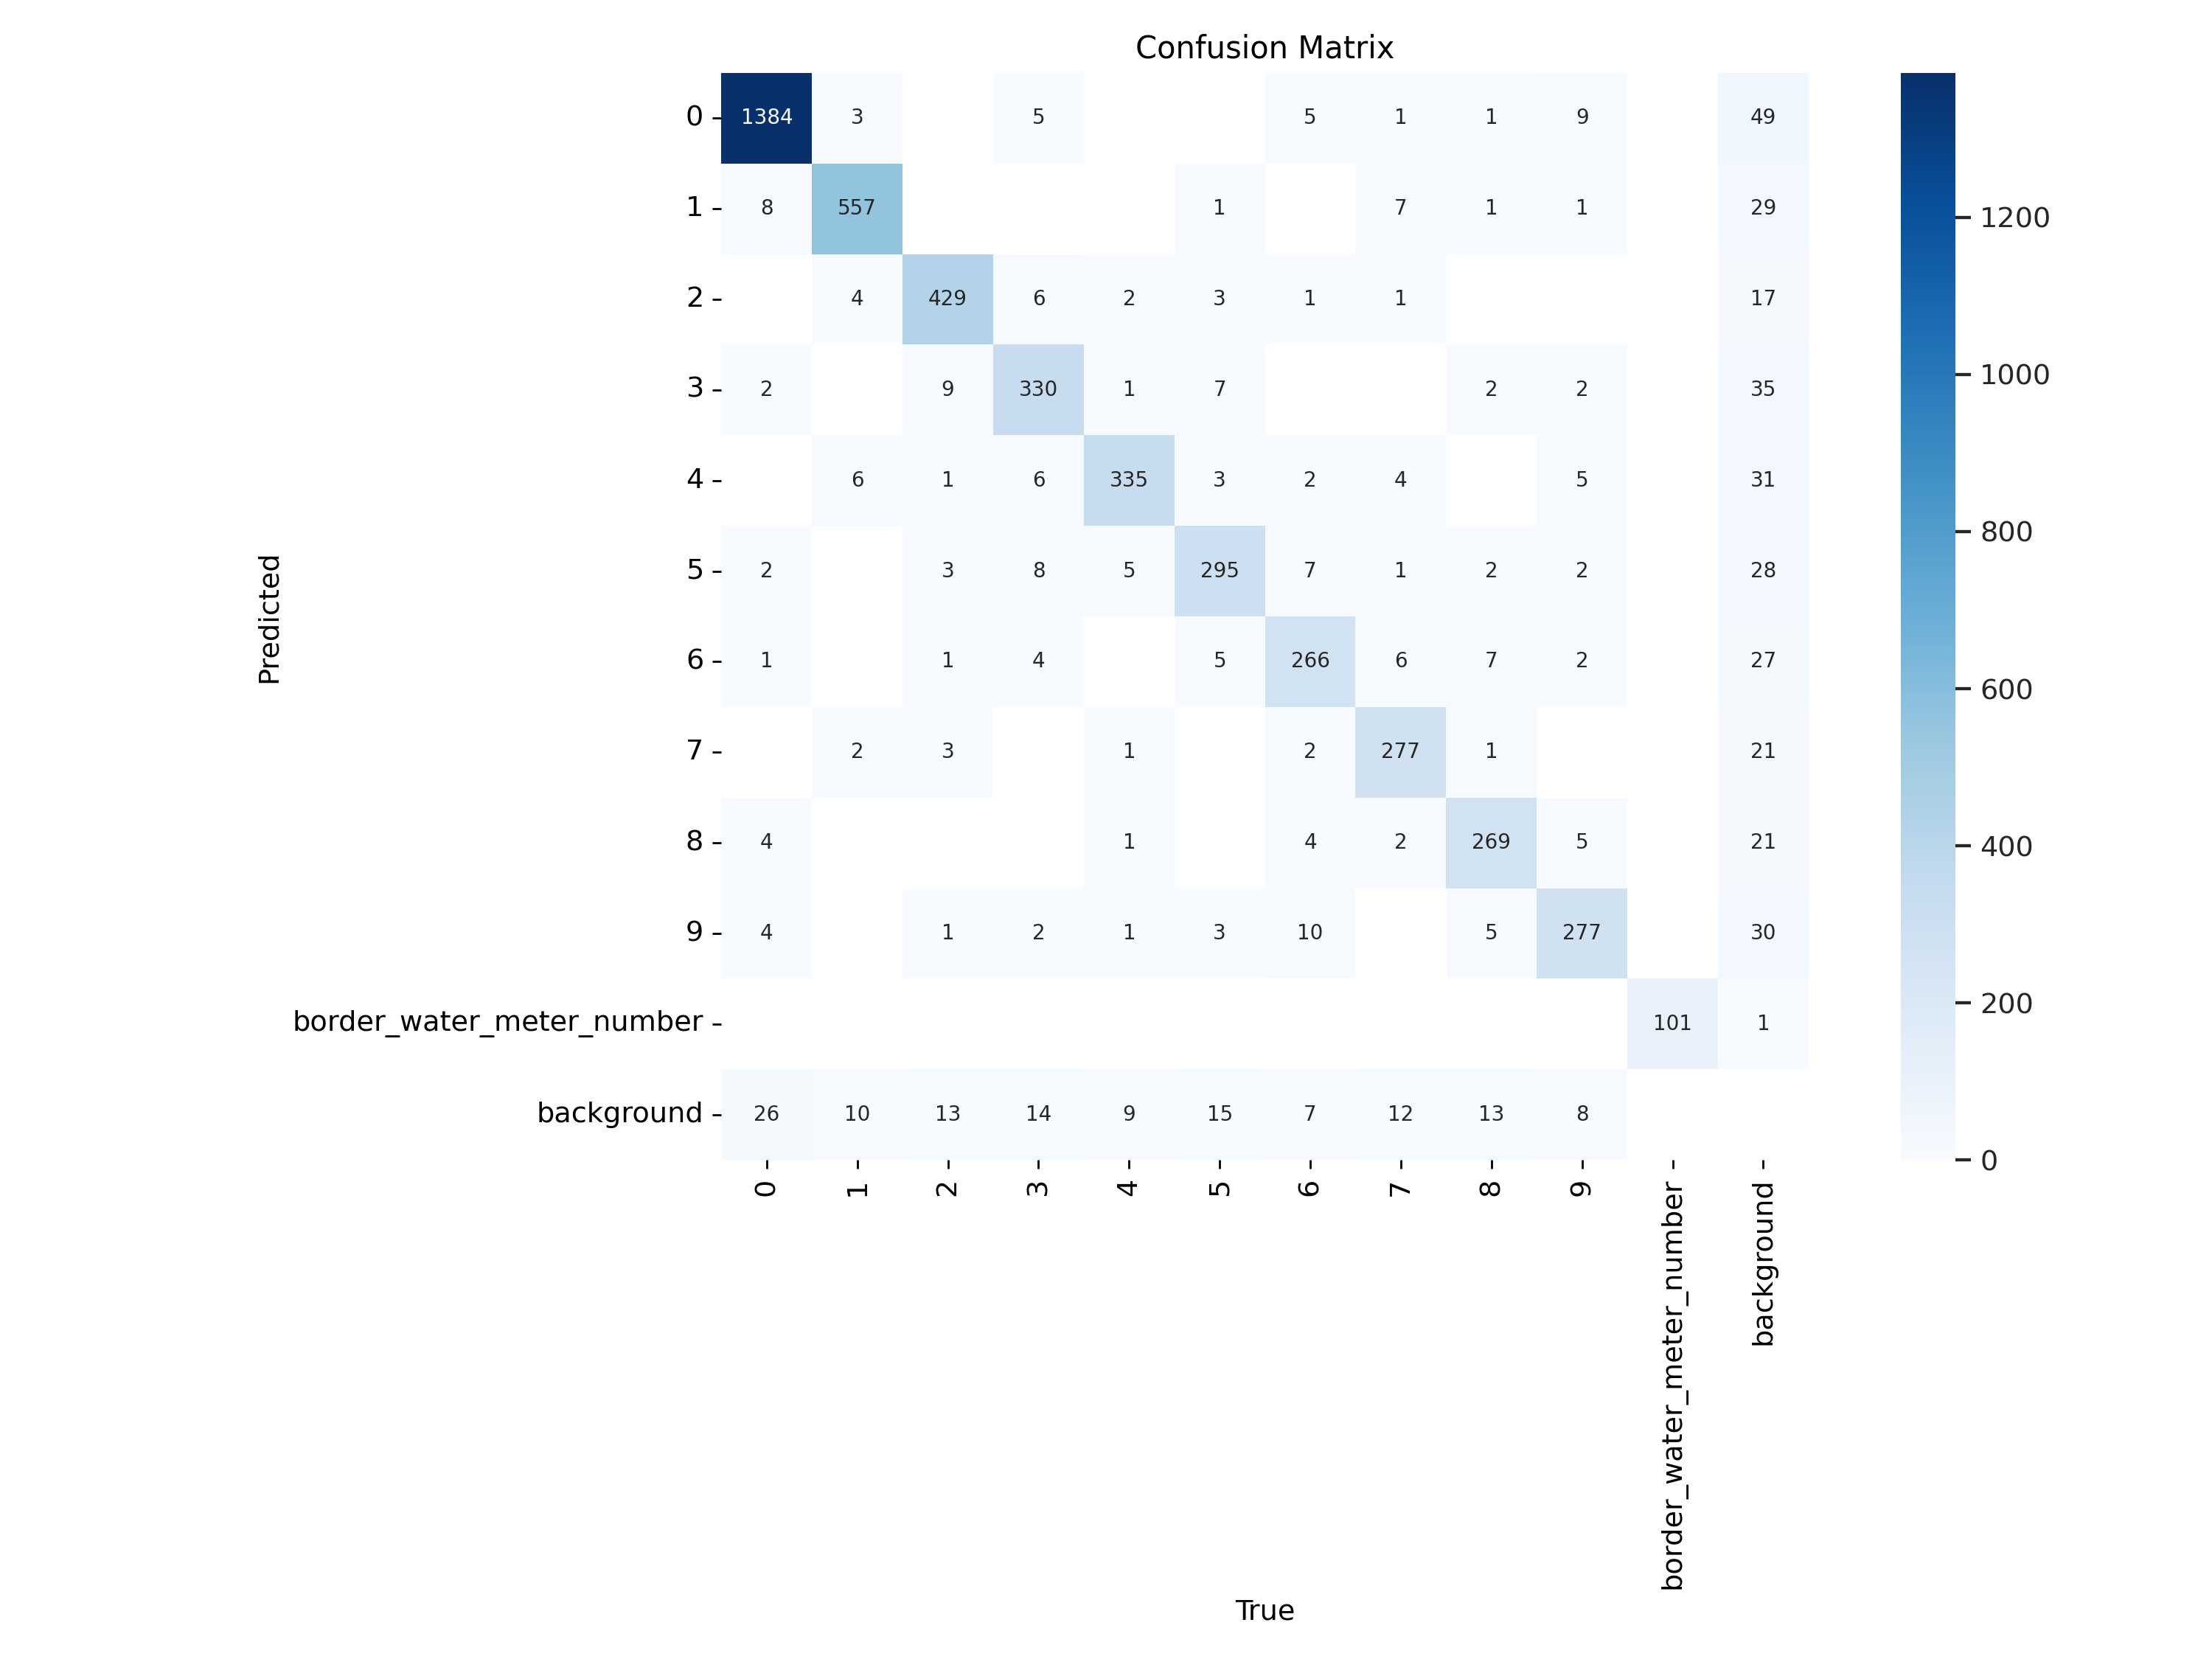

In [15]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

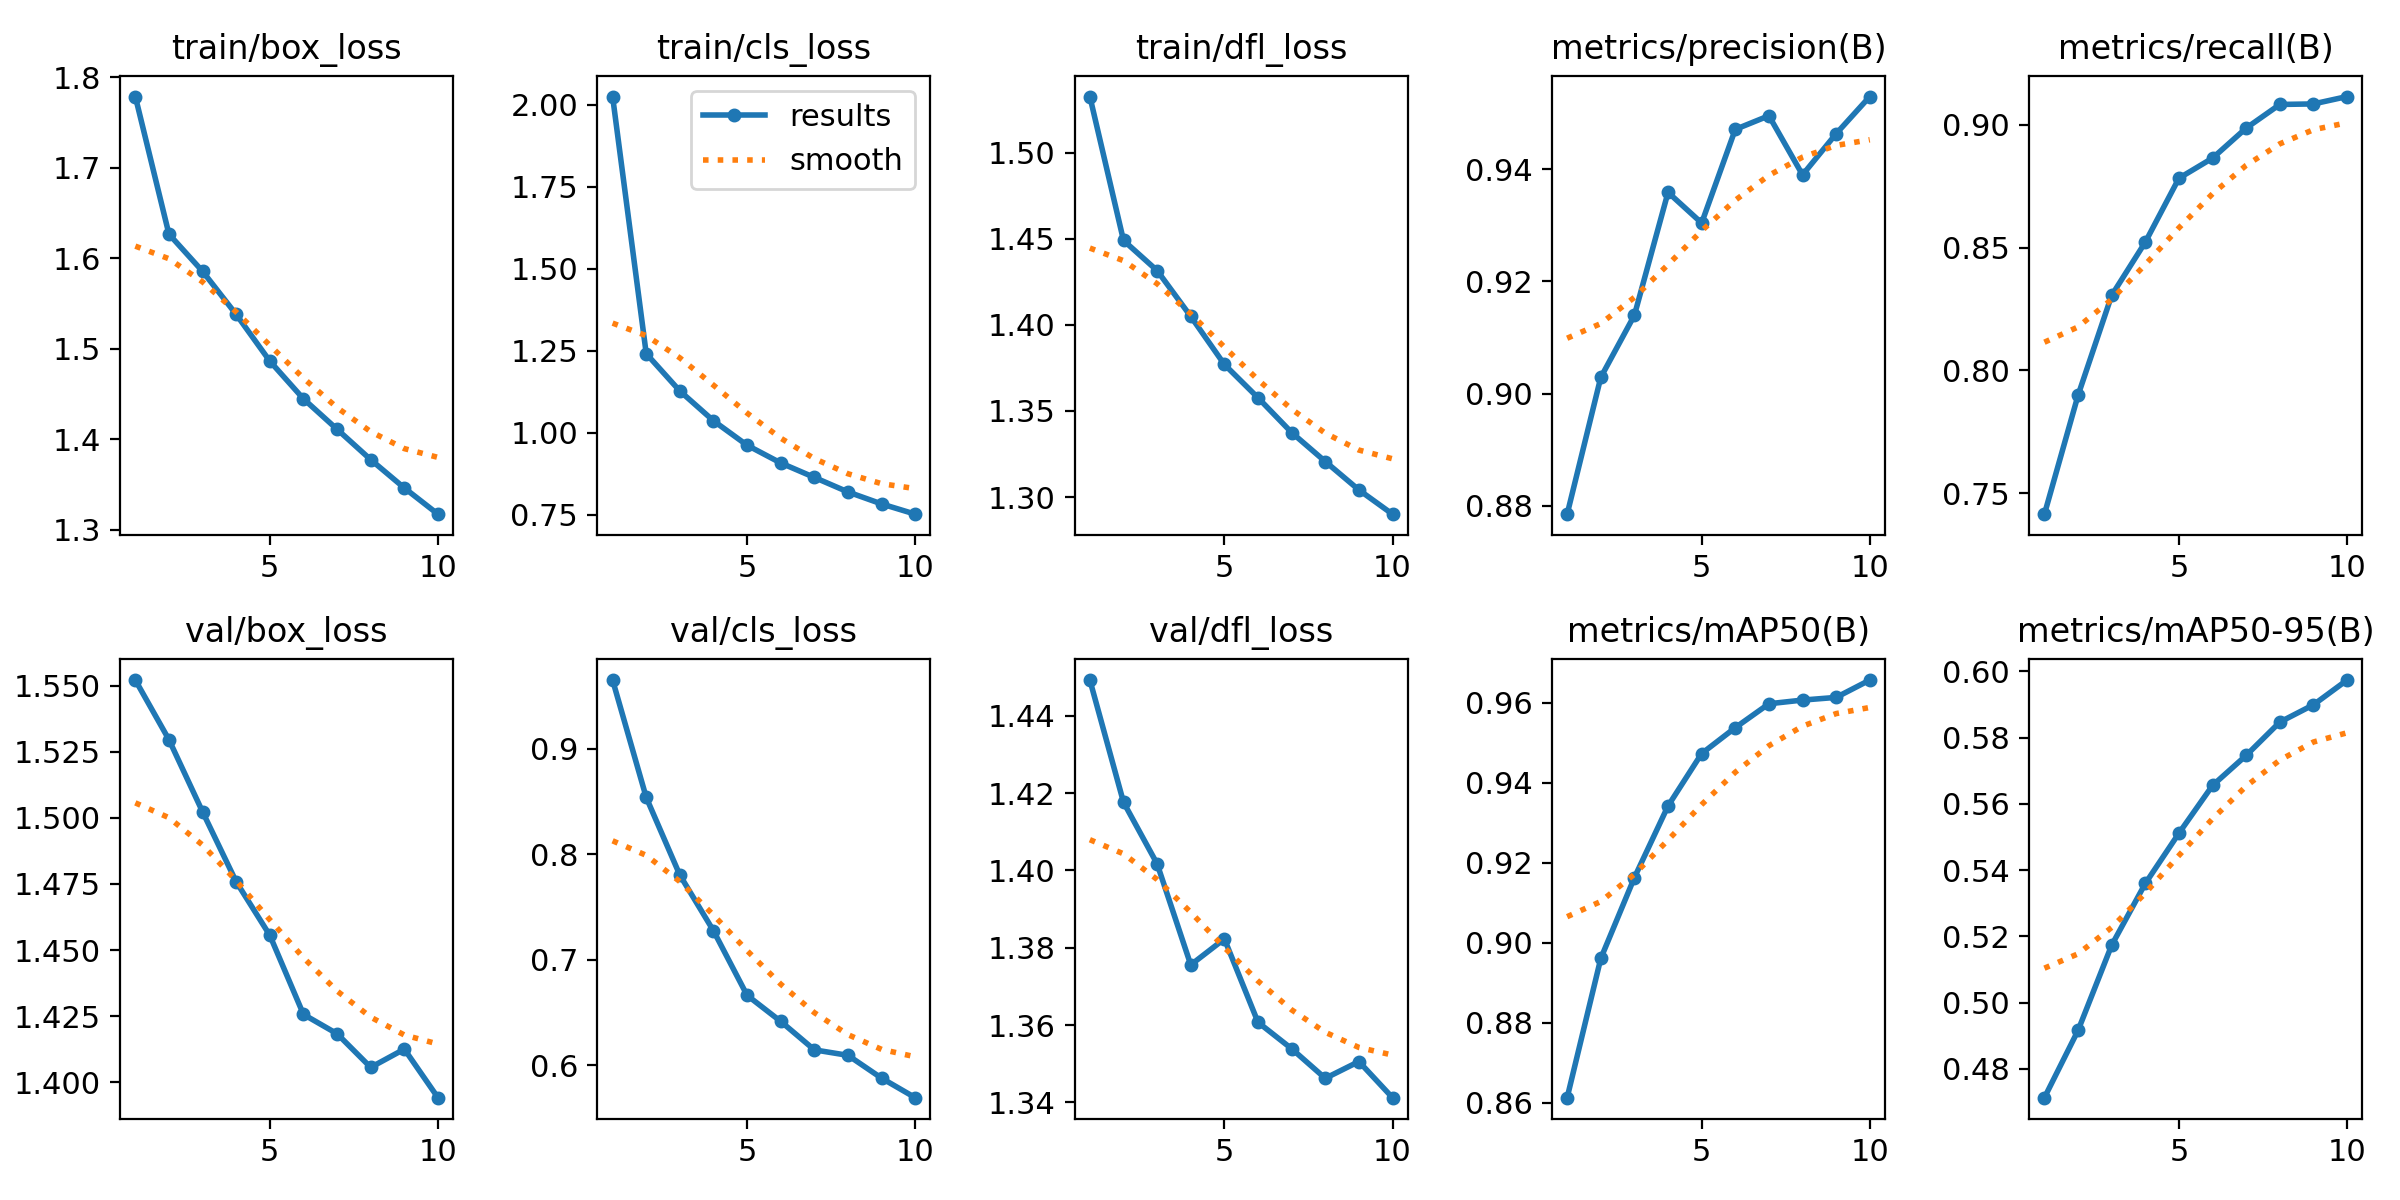

In [16]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

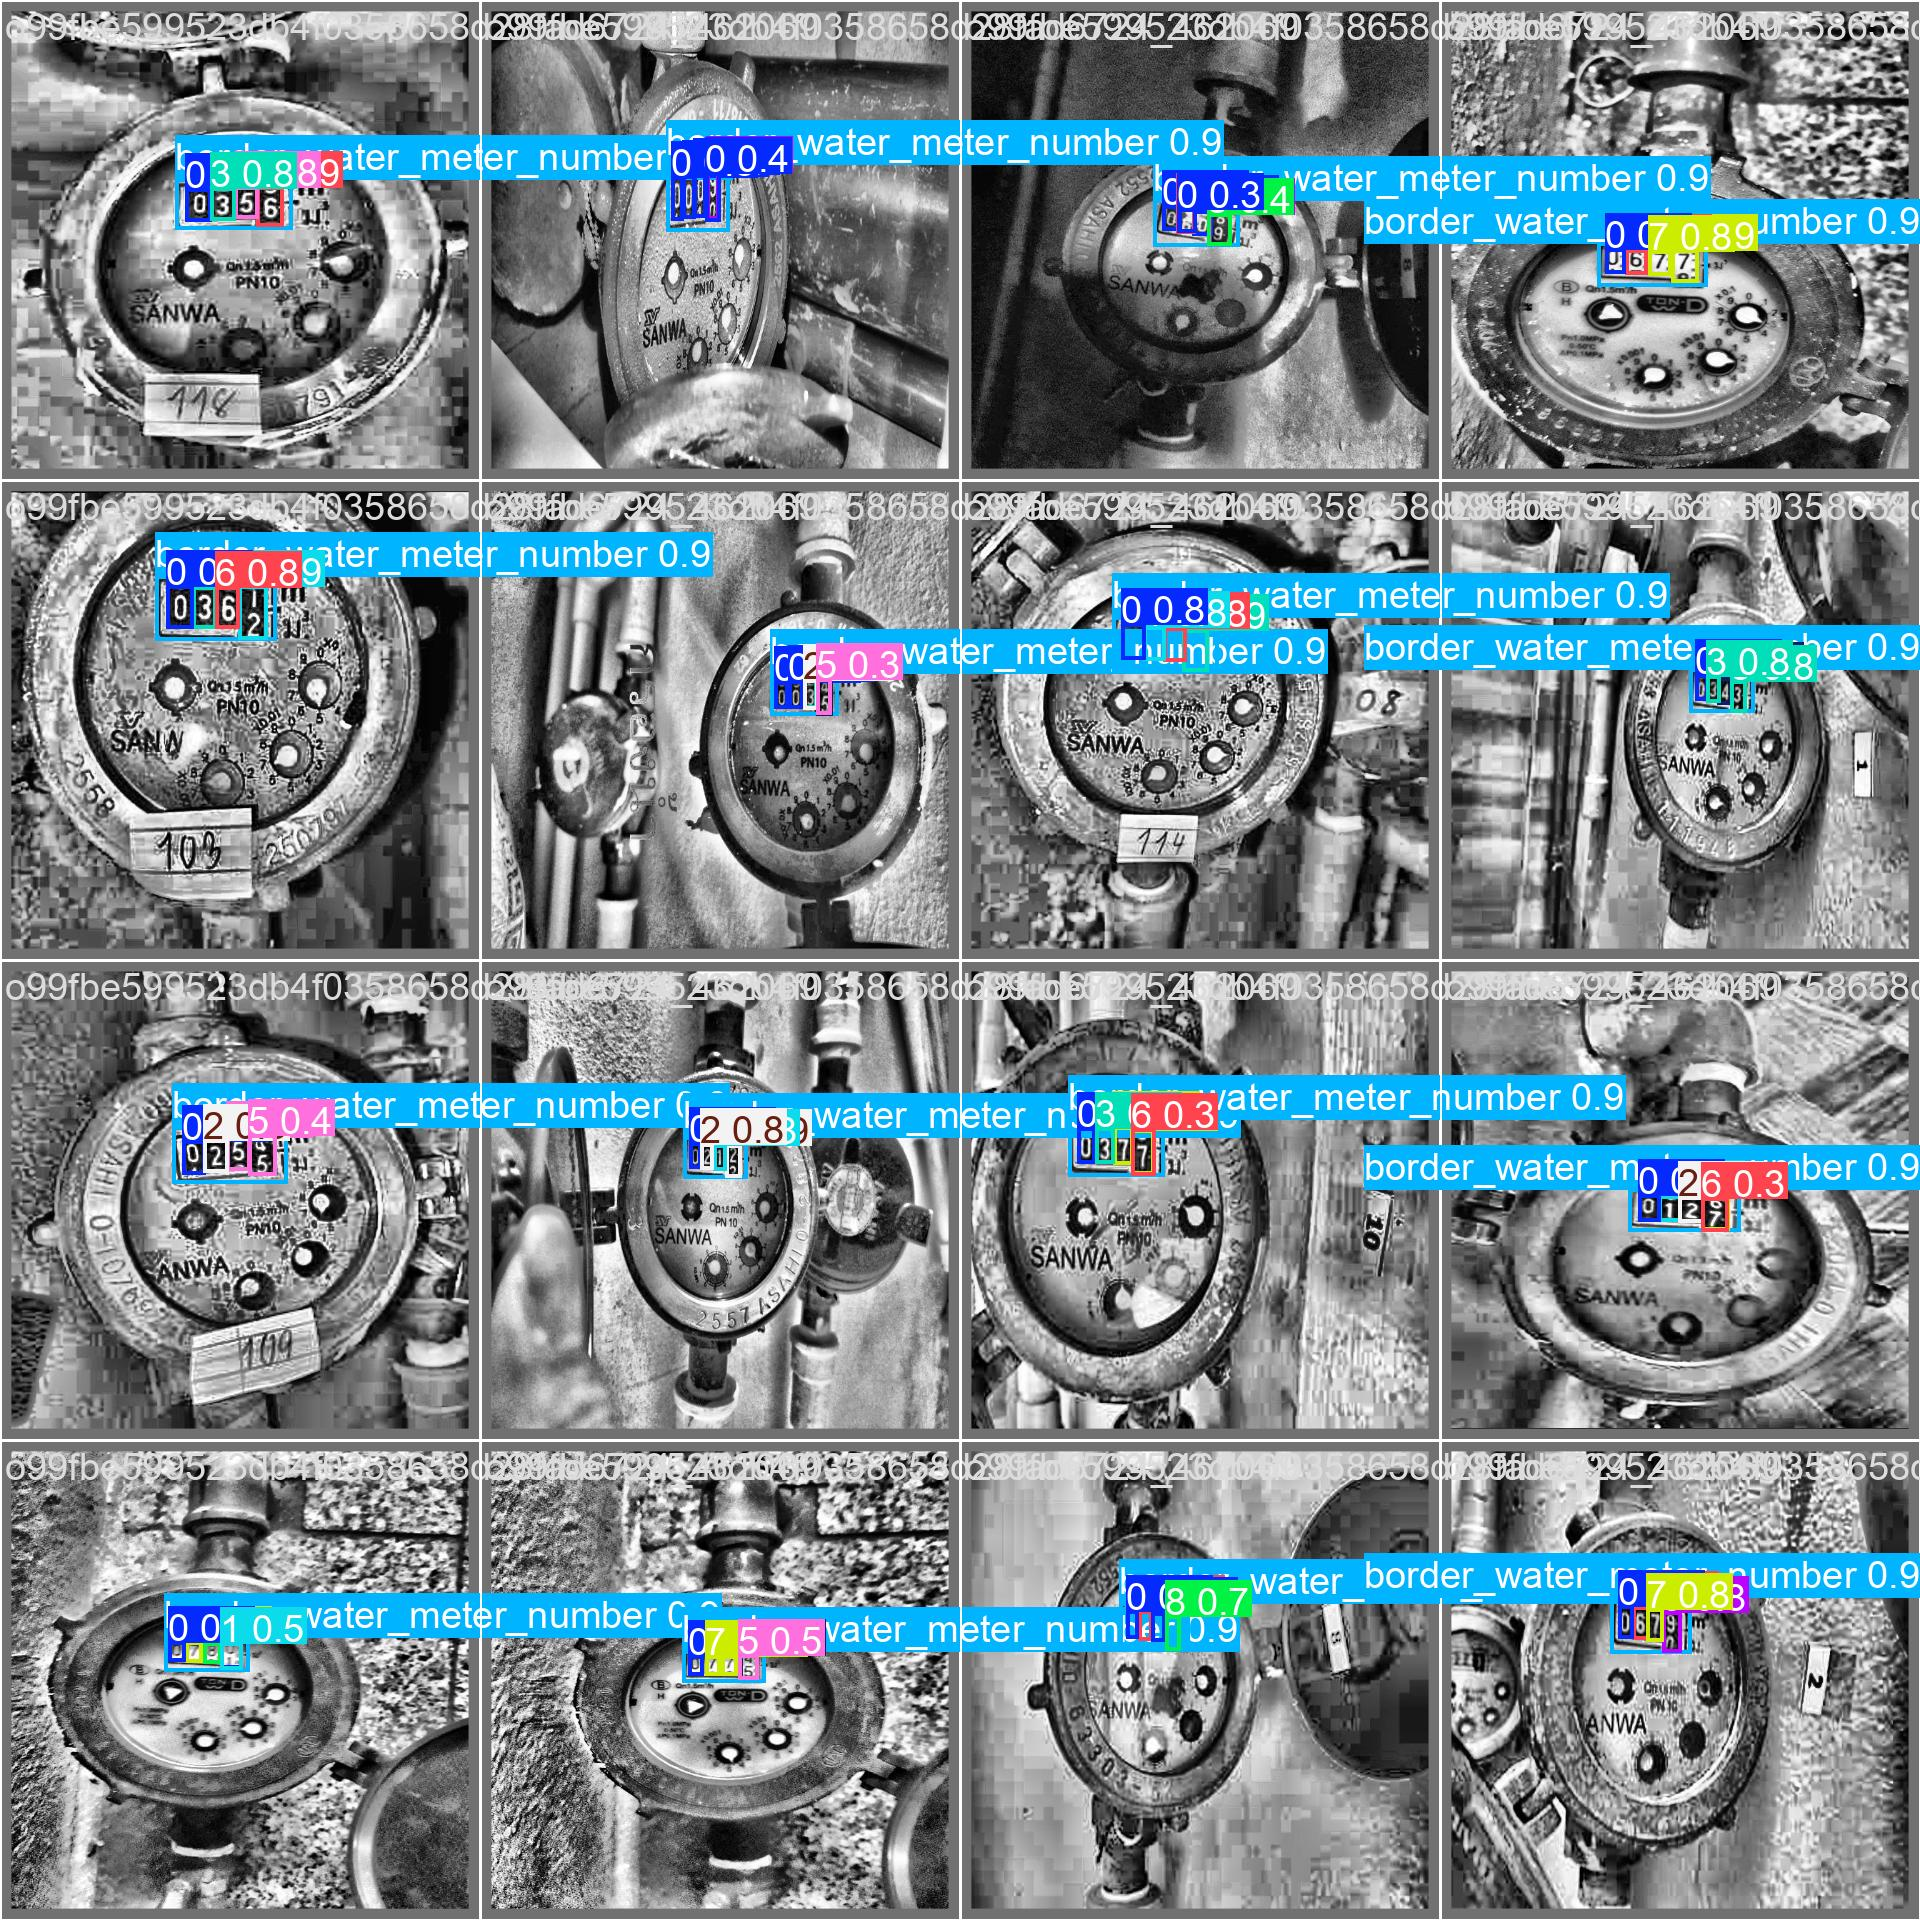

In [17]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## Validate fine-tuned model

In [18]:
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs
val: Scanning /content/datasets/Water-Meter-Dataset-3/valid/labels.cache... 795 images, 0 backgrounds, 0 corrupt: 100% 795/795 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 50/50 [00:12<00:00,  4.07it/s]
                   all        795       4863      0.953      0.912      0.966      0.599
                     0        771       1431       0.97       0.96      0.985      0.606
                     1        436        582       0.96      0.942      0.977      0.573
                     2        356        460      0.966      0.917      0.982       0.59
                     3        303        375      0.947      0.865      0.959       0.57
                     4        295        355      0.932      0.932      0.969      0.568
                     5        

## Inference with custom model

In [19]:
!yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={dataset.location}/test/images save=True

Ultralytics 8.3.40 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 238 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs

image 1/679 /content/datasets/Water-Meter-Dataset-3/test/images/FLODIS3I_2012_6012_1_jpg.rf.4ab2c2a25697f3543ff7a6a054cf1ef4.jpg: 640x640 2 0s, 1 1, 1 2, 1 3, 1 6, 15.6ms
image 2/679 /content/datasets/Water-Meter-Dataset-3/test/images/FLODIS3I_2013_3325_1_jpg.rf.5827bf80845a71e18fc81c89fef5c199.jpg: 640x640 1 2, 1 3, 1 5, 1 6, 1 7, 15.6ms
image 3/679 /content/datasets/Water-Meter-Dataset-3/test/images/FLODIS3I_2013_6285_1_jpg.rf.5ec5cf0f85cc6fe55667df3d3dd29828.jpg: 640x640 1 2, 2 5s, 2 6s, 1 8, 15.6ms
image 4/679 /content/datasets/Water-Meter-Dataset-3/test/images/M170EVO_2015_1452_1_jpg.rf.51514761b0605daa933f4eb18c9840f6.jpg: 640x640 3 1s, 1 2, 2 4s, 1 5, 15.6ms
image 5/679 /content/datasets/Water-Meter-Dataset-3/test/images/M170EVO_2015_3757_1_jpg.rf.8ec5fa443bc783a7102da7acb2dd878e.jpg: 640x640 1 0, 1 2, 1 4, 3 7s, 1

**NOTE:** Let's take a look at few results.

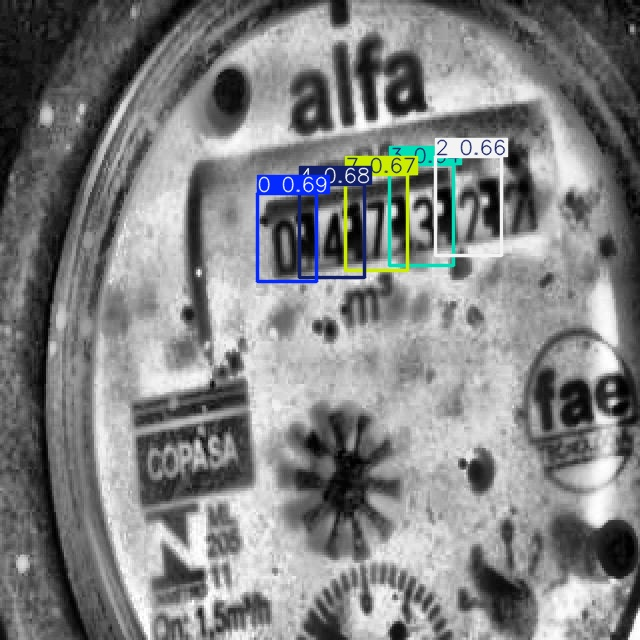

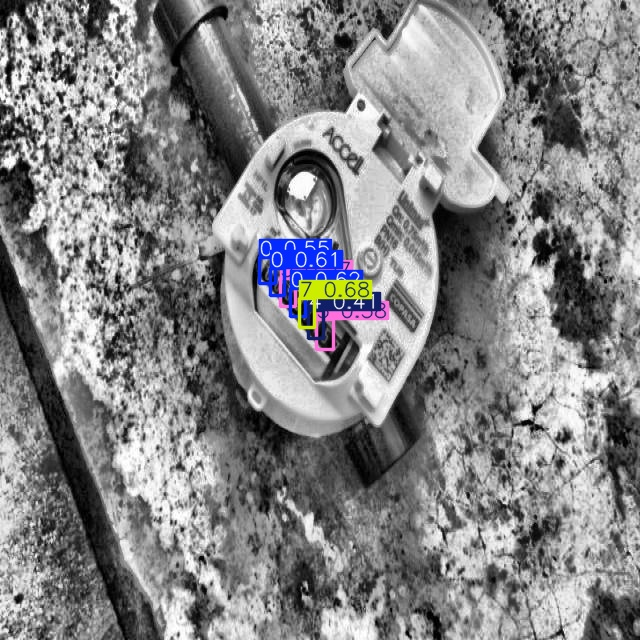

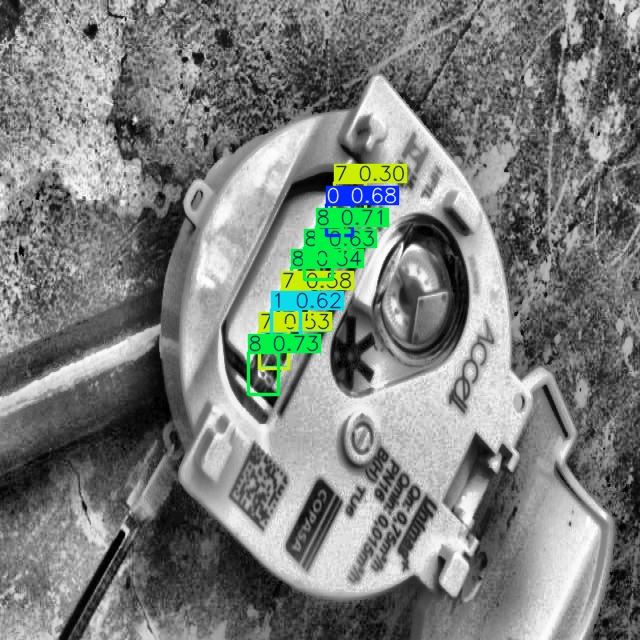

In [20]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## Deploy model on Roboflow

Once you have finished training your YOLOv11 model, you’ll have a set of trained weights ready for use. These weights will be in the `/runs/detect/train/weights/best.pt` folder of your project. You can upload your model weights to Roboflow Deploy to use your trained weights on our infinitely scalable infrastructure.

The `.deploy()` function in the [Roboflow pip package](https://docs.roboflow.com/python) now supports uploading YOLOv11 weights.

In [21]:
project.version(dataset.version).deploy(model_type="yolov11", model_path=f"{HOME}/runs/detect/train/")

An error occured when getting the model upload URL: This version already has a trained model. Please generate and train a new version in order to upload model to Roboflow.


In [ ]:
!pip install inference

Running inference on TUIVICV_1637695555722_jpg.rf.f05845ff9d700178fa87e46a78f02ca3.jpg


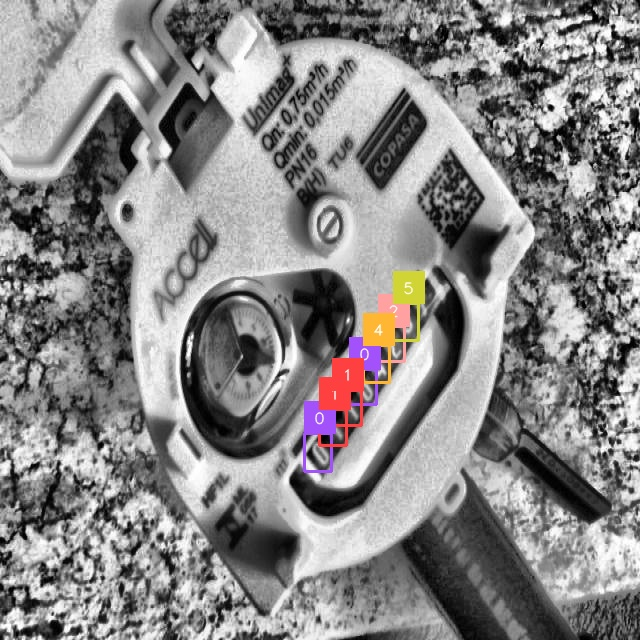

Running inference on TUIVICV_1637862381153_jpg.rf.a6d89f19a1f2df366903fccd2df5d1ba.jpg


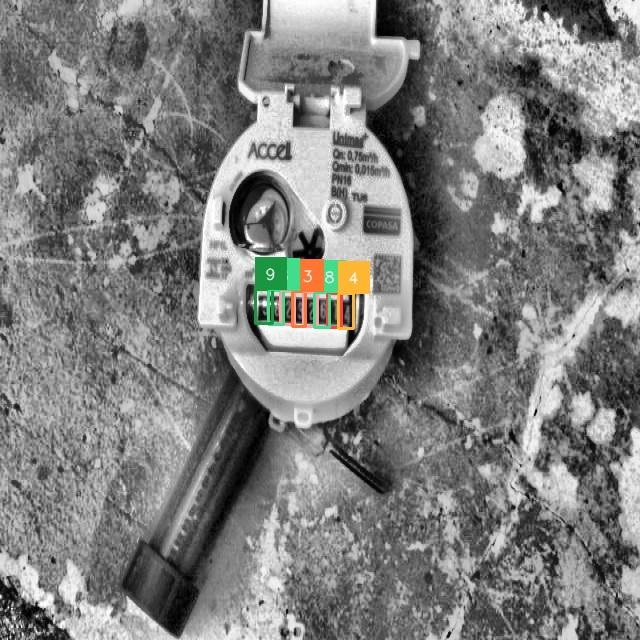

Running inference on US15_2020_236_4_jpg.rf.e643ade13a8f7d555ec82d93f23059eb.jpg


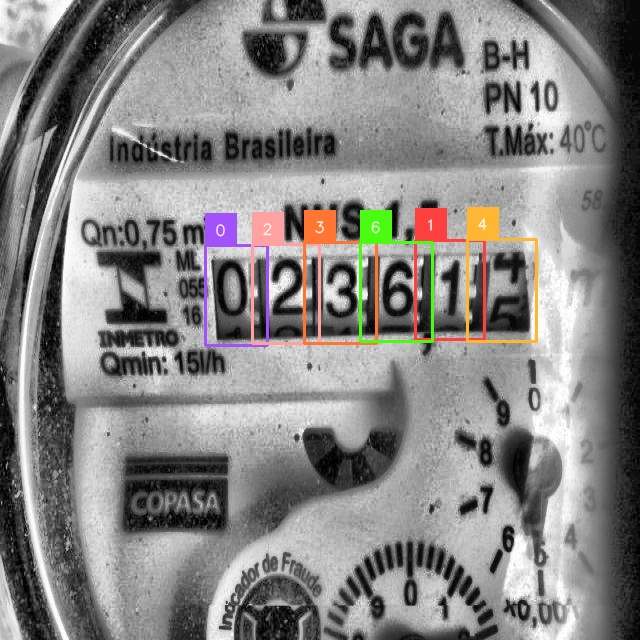

Running inference on US15_2019_239_3_jpg.rf.5de1e73897c6da64fff2b25352e97320.jpg


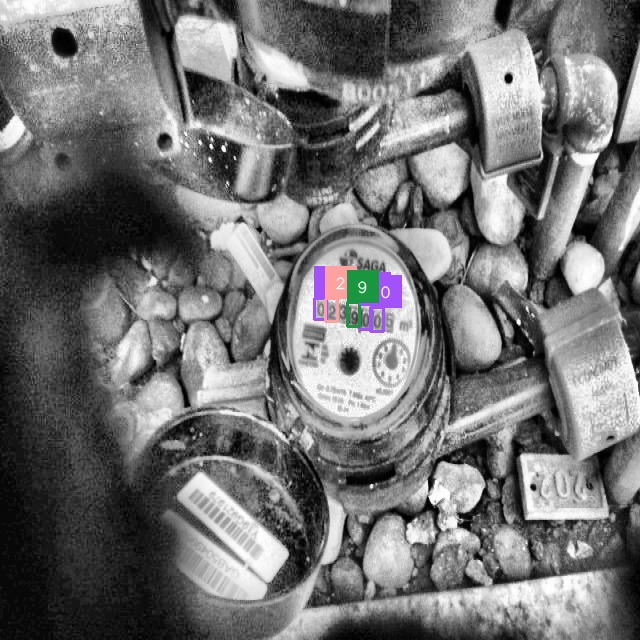

In [27]:
import os, random, cv2
import supervision as sv
import IPython
from ultralytics import YOLO # Import YOLO for local model loading

# Load the locally trained YOLO11 model
model = YOLO(f"{HOME}/runs/detect/train/weights/best.pt")

# Location of test set images
test_set_loc = dataset.location + "/test/images/"
test_images = os.listdir(test_set_loc)

# Run inference on 4 random test images, or fewer if fewer images are available
for img_name in random.sample(test_images, min(4, len(test_images))):
    print("Running inference on " + img_name)

    # Load image
    image = cv2.imread(os.path.join(test_set_loc, img_name))

    # Perform inference using model.predict for Ultralytics models
    results_list = model.predict(source=image, conf=0.4, iou=0.3, verbose=False)
    results = results_list[0] # Get the Results object for the current image
    detections = sv.Detections.from_ultralytics(results) # Convert using from_ultralytics

    # Annotate boxes and labels
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections)
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections)

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)


Saving 00002029-PHOTO-2025-12-22-14-25-29.jpg to 00002029-PHOTO-2025-12-22-14-25-29.jpg
User uploaded file "00002029-PHOTO-2025-12-22-14-25-29.jpg" with length 237808 bytes
Running inference on uploaded image: 00002029-PHOTO-2025-12-22-14-25-29.jpg

All detected bounding boxes and class IDs (before filtering):
  BBox: [     1061.7      581.06      1111.9       667.5], Class ID: 6
  BBox: [     994.81      586.19      1040.2      669.15], Class ID: 2
  BBox: [     926.35      586.85      975.31      671.65], Class ID: 8
  BBox: [     860.23      586.28      906.16      671.84], Class ID: 8
  BBox: [     791.82      587.45      841.09      672.74], Class ID: 4
  BBox: [      707.5      571.45      1142.7      680.95], Class ID: 10
  BBox: [     728.61       585.2      771.37       677.8], Class ID: 0
Detected Meter Reading: 048826


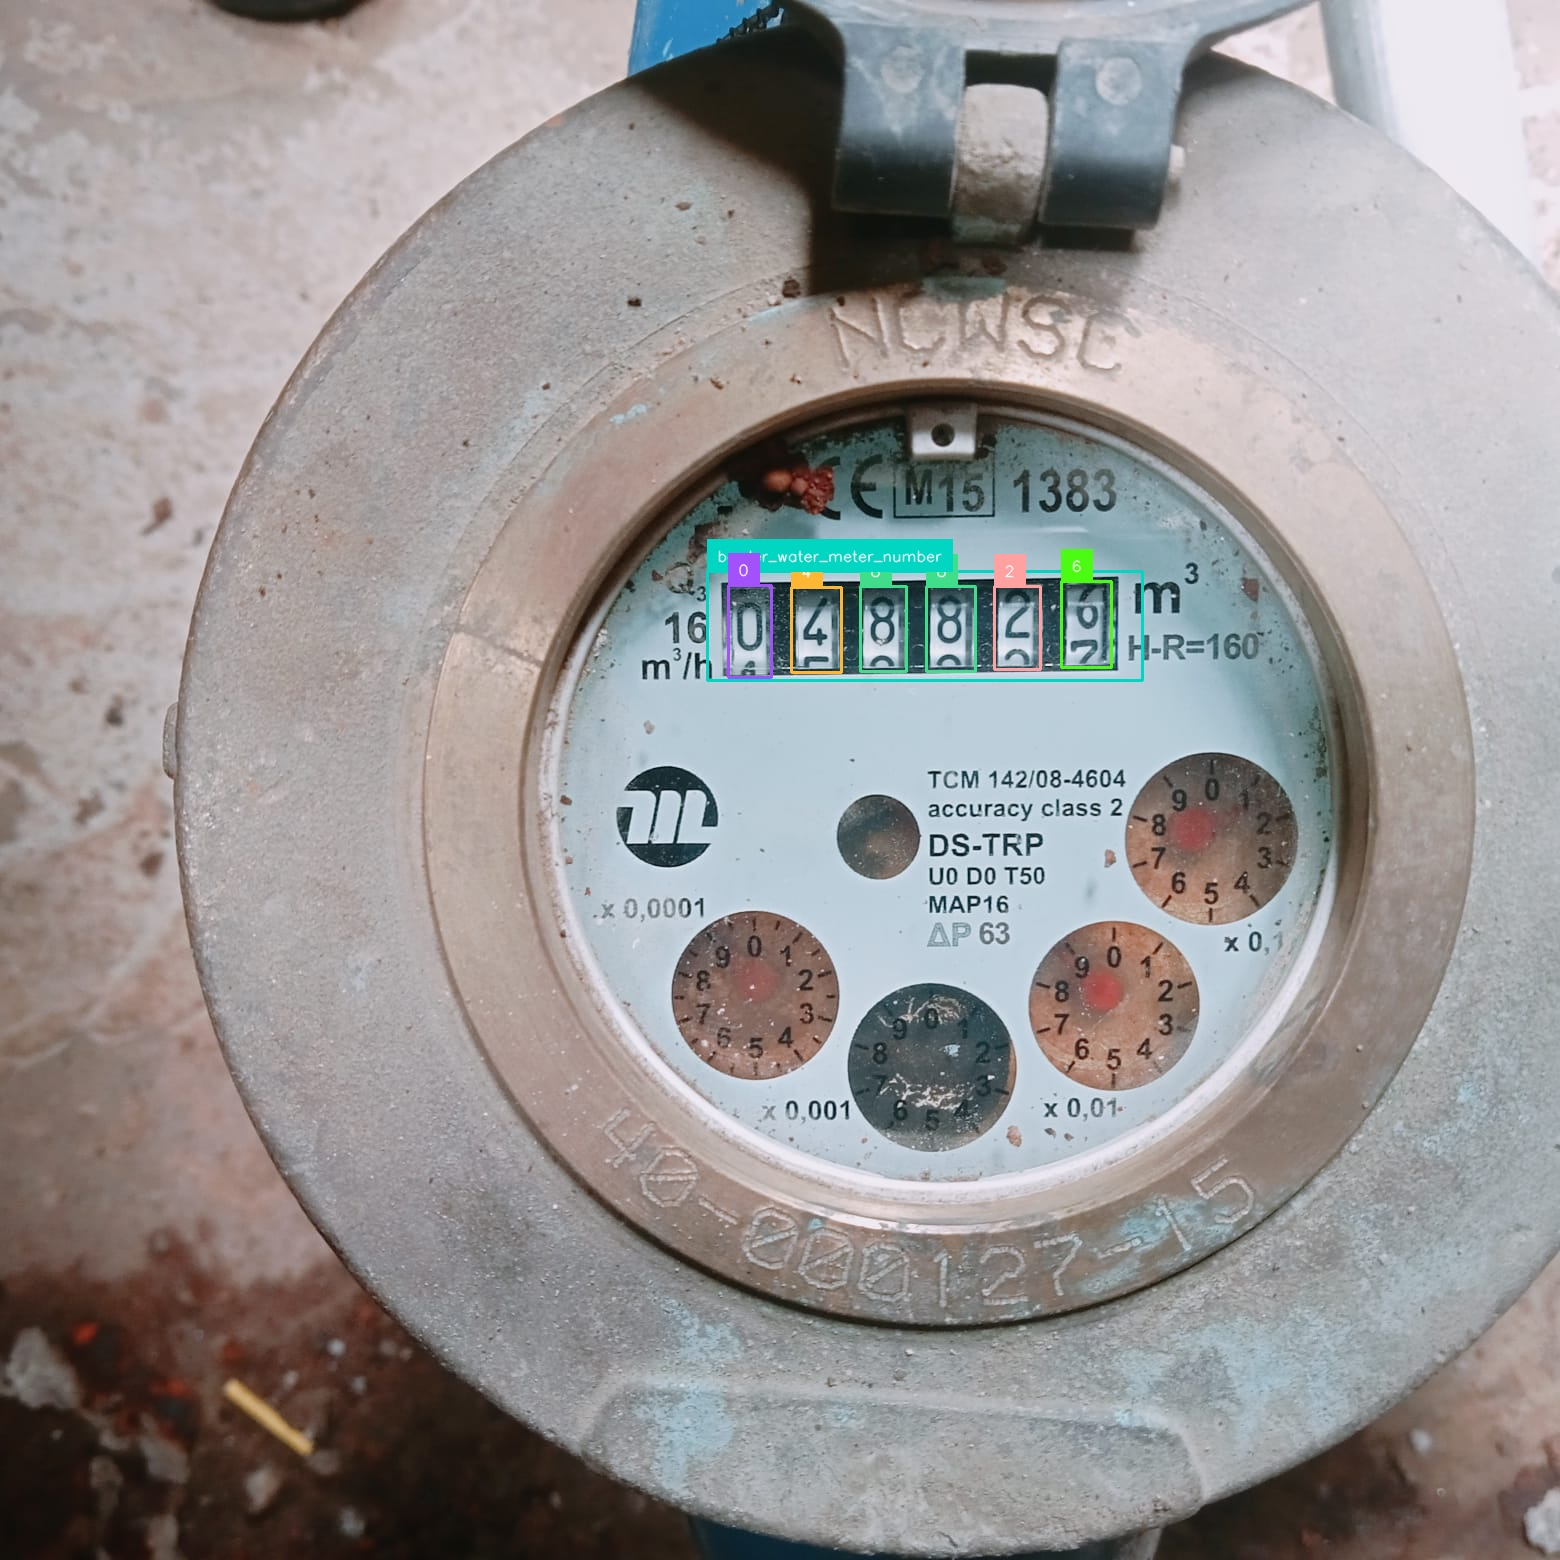

In [31]:
from google.colab import files
import cv2
import numpy as np
import supervision as sv
import IPython.display

# Ensure the 'model' object is available from previous cells
# If not, you may need to re-run cell BwYVU9S5znB2

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

  # Read image from uploaded content
  nparr = np.frombuffer(uploaded[fn], np.uint8)
  image = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

  if image is not None:
    print(f"Running inference on uploaded image: {fn}")
    # Perform inference
    # confidence and overlap values can be adjusted if needed
    # Use model.predict() for Ultralytics models and adjust parameters accordingly
    results_list = model.predict(source=image, conf=0.4, iou=0.3, verbose=False)
    results = results_list[0] # Get the Results object for the current image
    detections = sv.Detections.from_ultralytics(results)

    print("\nAll detected bounding boxes and class IDs (before filtering):")
    if len(detections.xyxy) > 0:
        for bbox, class_id in zip(detections.xyxy, detections.class_id):
            print(f"  BBox: {bbox}, Class ID: {class_id}")
    else:
        print("  No detections found.")

    # Filter out 'border_water_meter_number' if it exists and separate digits
    digit_detections = detections[detections.class_id < 10] # Class IDs 0-9 for digits

    # Sort digits by their x-coordinate to get the correct order
    if len(digit_detections.xyxy) > 0:
        sorted_indices = np.argsort(digit_detections.xyxy[:, 0])
        sorted_digits_class_ids = digit_detections.class_id[sorted_indices]
        meter_reading = "".join([str(d) for d in sorted_digits_class_ids])
        print(f"Detected Meter Reading: {meter_reading}")
    else:
        print("No digits detected for meter reading.")

    # Annotate boxes and labels with ALL detections (not just digits)
    box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator()
    annotated_image = box_annotator.annotate(scene=image, detections=detections) # Use 'detections' here
    annotated_image = label_annotator.annotate(scene=annotated_image, detections=detections) # Use 'detections' here

    # Display annotated image
    _, ret = cv2.imencode('.jpg', annotated_image)
    i = IPython.display.Image(data=ret)
    IPython.display.display(i)
  else:
    print(f"Could not read image file: {fn}")

In [32]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 🏆 Congratulations

### Learning Resources

Roboflow has produced many resources that you may find interesting as you advance your knowledge of computer vision:

- [Roboflow Notebooks](https://github.com/roboflow/notebooks): A repository of over 20 notebooks that walk through how to train custom models with a range of model types, from YOLOv7 to SegFormer.
- [Roboflow YouTube](https://www.youtube.com/c/Roboflow): Our library of videos featuring deep dives into the latest in computer vision, detailed tutorials that accompany our notebooks, and more.
- [Roboflow Discuss](https://discuss.roboflow.com/): Have a question about how to do something on Roboflow? Ask your question on our discussion forum.
- [Roboflow Models](https://roboflow.com): Learn about state-of-the-art models and their performance. Find links and tutorials to guide your learning.

### Convert data formats

Roboflow provides free utilities to convert data between dozens of popular computer vision formats. Check out [Roboflow Formats](https://roboflow.com/formats) to find tutorials on how to convert data between formats in a few clicks.

### Connect computer vision to your project logic

[Roboflow Templates](https://roboflow.com/templates) is a public gallery of code snippets that you can use to connect computer vision to your project logic. Code snippets range from sending emails after inference to measuring object distance between detections.